<a href="https://colab.research.google.com/github/YukthiN/Machinelearning-/blob/main/ML_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_description.txt to data_description.txt
Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()

Shape: (1460, 81)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'S

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== BASIC INFO ===")
df.info()

print("\n=== STATISTICS ===")
df.describe()

=== SHAPE ===
(1460, 81)

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overall

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


=== COLUMNS WITH MISSING VALUES ===
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


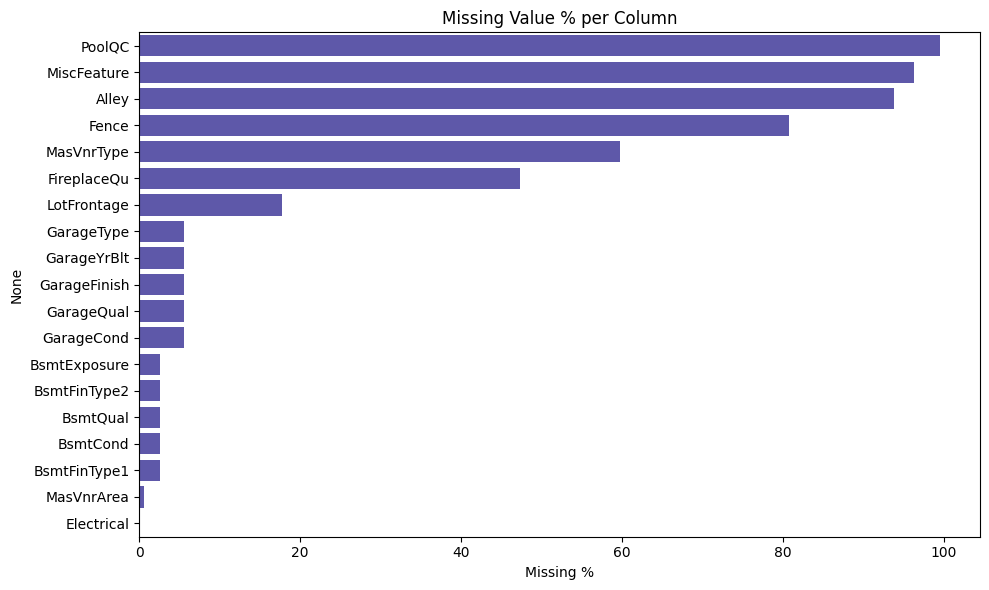

In [ ]:
# Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print("=== COLUMNS WITH MISSING VALUES ===")
print(missing_df)

# Visualise it
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='#534AB7')
plt.title('Missing Value % per Column')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

In [ ]:
# ── 1. Columns where missing = "None" (feature simply doesn't exist) ──
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# ── 2. Columns where missing = 0 (no garage, no basement etc.) ──
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# ── 3. Fill numeric columns with median ──
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# ── 4. Fill remaining categorical with mode ──
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ── Check ──
print("Missing values remaining:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Missing values remaining: 0
Shape after cleaning: (1460, 81)


In [ ]:
# ── Encode all categorical columns into numbers ──
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Encoding {len(cat_cols)} categorical columns...")

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# ── Create classification target (price buckets) ──

# Fix — use qcut for equal distribution
df['PriceCategory'] = pd.qcut(df['SalePrice'],
                                q=3,
                                labels=[0, 1, 2])  # 0=Low, 1=Mid, 2=High
df['PriceCategory'] = df['PriceCategory'].astype(int)

print("Price category distribution:")
print(df['PriceCategory'].value_counts().sort_index())
print("\nPrice ranges per category:")
print(pd.qcut(df['SalePrice'], q=3).value_counts().sort_index())





Encoding 0 categorical columns...
Price category distribution:
PriceCategory
0    487
1    490
2    483
Name: count, dtype: int64

Price ranges per category:
SalePrice
(34899.999, 139700.0]    487
(139700.0, 190000.0]     490
(190000.0, 755000.0]     483
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['SalePrice', 'PriceCategory', 'Id'], axis=1)
y_reg = df['SalePrice']
y_cls = df['PriceCategory']

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("Ready!")

Training set: (1168, 79)
Test set:     (292, 79)
Ready!


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

reg_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=1.0),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN'               : KNeighborsRegressor(n_neighbors=5),
    'SVR'               : SVR(kernel='rbf'),
}

reg_results = {}
print("Training regression models...\n")

for name, model in reg_models.items():
    if name in ['KNN', 'SVR', 'Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_sc, yr_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, yr_train)
        preds = model.predict(X_test)

    mse  = mean_squared_error(yr_test, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yr_test, preds)
    r2   = r2_score(yr_test, preds)

    reg_results[name] = {
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2, 4)
    }
    print(f"✅ {name} — RMSE: {rmse:,.0f} | R²: {r2:.4f}")

print("\nAll regression models done!")

Training regression models...

✅ Linear Regression — RMSE: 34,656 | R²: 0.8434
✅ Ridge — RMSE: 34,641 | R²: 0.8436
✅ Lasso — RMSE: 34,654 | R²: 0.8434
✅ Decision Tree — RMSE: 40,991 | R²: 0.7809
✅ Random Forest — RMSE: 28,338 | R²: 0.8953
✅ KNN — RMSE: 41,117 | R²: 0.7796
✅ SVR — RMSE: 88,639 | R²: -0.0243

All regression models done!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

cls_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf'),
    'Naive Bayes'         : GaussianNB(),
}

cls_results = {}
print("Training classification models...\n")

for name, model in cls_models.items():
    if name in ['Logistic Regression', 'KNN', 'SVM']:
        model.fit(X_train_sc, yc_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, yc_train)
        preds = model.predict(X_test)

    acc = accuracy_score(yc_test, preds)
    f1  = f1_score(yc_test, preds, average='weighted')

    cls_results[name] = {
        'Accuracy': round(acc * 100, 2),
        'F1 Score': round(f1, 4)
    }
    print(f"✅ {name} — Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")

print("\nAll classification models done!")

Training classification models...

✅ Logistic Regression — Accuracy: 92.47% | F1: 0.9197
✅ Decision Tree — Accuracy: 92.47% | F1: 0.9215
✅ Random Forest — Accuracy: 94.86% | F1: 0.9408
✅ KNN — Accuracy: 92.81% | F1: 0.9205
✅ SVM — Accuracy: 94.52% | F1: 0.9383
✅ Naive Bayes — Accuracy: 78.77% | F1: 0.8270

All classification models done!


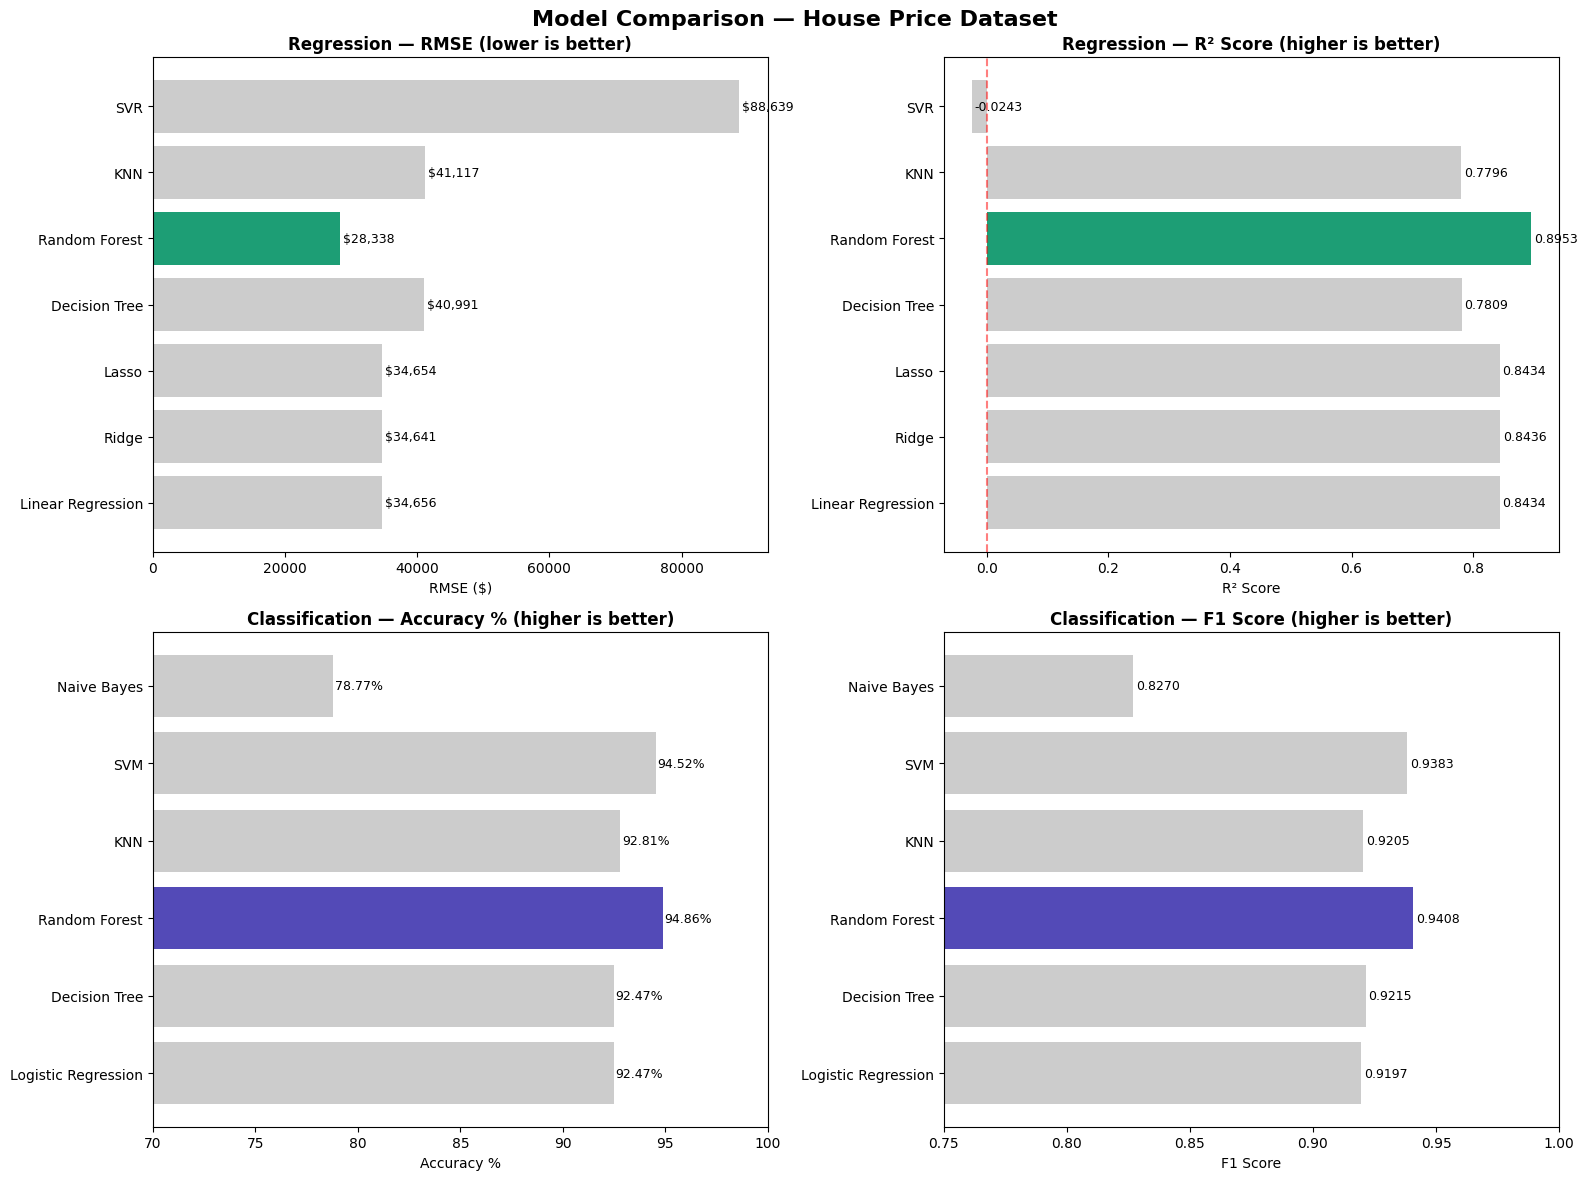

Chart saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison — House Price Dataset', fontsize=16, fontweight='bold')

# ── 1. RMSE comparison (lower is better) ──
reg_names = list(reg_results.keys())
rmse_vals  = [reg_results[m]['RMSE'] for m in reg_names]
r2_vals    = [reg_results[m]['R²']   for m in reg_names]

colors_reg = ['#1D9E75' if v == min(rmse_vals) else '#CCCCCC' for v in rmse_vals]
axes[0,0].barh(reg_names, rmse_vals, color=colors_reg)
axes[0,0].set_title('Regression — RMSE (lower is better)', fontweight='bold')
axes[0,0].set_xlabel('RMSE ($)')
for i, v in enumerate(rmse_vals):
    axes[0,0].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

# ── 2. R² comparison (higher is better) ──
colors_r2 = ['#1D9E75' if v == max(r2_vals) else '#CCCCCC' for v in r2_vals]
axes[0,1].barh(reg_names, r2_vals, color=colors_r2)
axes[0,1].set_title('Regression — R² Score (higher is better)', fontweight='bold')
axes[0,1].set_xlabel('R² Score')
axes[0,1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(r2_vals):
    axes[0,1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# ── 3. Accuracy comparison ──
cls_names = list(cls_results.keys())
acc_vals   = [cls_results[m]['Accuracy'] for m in cls_names]
f1_vals    = [cls_results[m]['F1 Score'] for m in cls_names]

colors_acc = ['#534AB7' if v == max(acc_vals) else '#CCCCCC' for v in acc_vals]
axes[1,0].barh(cls_names, acc_vals, color=colors_acc)
axes[1,0].set_title('Classification — Accuracy % (higher is better)', fontweight='bold')
axes[1,0].set_xlabel('Accuracy %')
axes[1,0].set_xlim(70, 100)
for i, v in enumerate(acc_vals):
    axes[1,0].text(v + 0.1, i, f'{v}%', va='center', fontsize=9)

# ── 4. F1 Score comparison ──
colors_f1 = ['#534AB7' if v == max(f1_vals) else '#CCCCCC' for v in f1_vals]
axes[1,1].barh(cls_names, f1_vals, color=colors_f1)
axes[1,1].set_title('Classification — F1 Score (higher is better)', fontweight='bold')
axes[1,1].set_xlabel('F1 Score')
axes[1,1].set_xlim(0.75, 1.0)
for i, v in enumerate(f1_vals):
    axes[1,1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
print("=" * 60)
print("REGRESSION RESULTS")
print("=" * 60)
print(f"{'Model':<20} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print("-" * 60)
for m in reg_names:
    r = reg_results[m]
    marker = " ← WINNER" if r['RMSE'] == min(rmse_vals) else ""
    marker = " ← WORST"  if r['RMSE'] == max(rmse_vals) else marker
    print(f"{m:<20} ${r['RMSE']:>10,.0f} ${r['MAE']:>10,.0f} {r['R²']:>8.4f}{marker}")

print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 60)
for m in cls_names:
    r = cls_results[m]
    marker = " ← WINNER" if r['Accuracy'] == max(acc_vals) else ""
    marker = " ← WORST"  if r['Accuracy'] == min(acc_vals) else marker
    print(f"{m:<22} {r['Accuracy']:>9}% {r['F1 Score']:>10.4f}{marker}")

REGRESSION RESULTS
Model                        RMSE          MAE       R²
------------------------------------------------------------
Linear Regression    $    34,656 $    21,575   0.8434
Ridge                $    34,641 $    21,565   0.8436
Lasso                $    34,654 $    21,573   0.8434
Decision Tree        $    40,991 $    27,144   0.7809
Random Forest        $    28,338 $    17,476   0.8953 ← WINNER
KNN                  $    41,117 $    23,954   0.7796
SVR                  $    88,639 $    59,532  -0.0243 ← WORST

CLASSIFICATION RESULTS
Model                    Accuracy   F1 Score
------------------------------------------------------------
Logistic Regression        92.47%     0.9197
Decision Tree              92.47%     0.9215
Random Forest              94.86%     0.9408 ← WINNER
KNN                        92.81%     0.9205
SVM                        94.52%     0.9383
Naive Bayes                78.77%     0.8270 ← WORST



                ╔══════════════════════════════════════════════════════════════╗
                ║              FINAL VERDICT — WHICH MODEL WINS?               ║
                ╠══════════════════════════════════════════════════════════════╣
                ║                                                              ║
                ║  REGRESSION WINNER: Random Forest                            ║
                ║  → RMSE: $28,338  (predicts within ~$28k of actual price)    ║
                ║  → R²: 0.8953  (explains 89.5% of price variance)            ║
                ║  → 18% better RMSE than Linear Regression                    ║
                ║                                                              ║
                ║  REGRESSION LOSER: SVR                                       ║
                ║  → R²: -0.0243  (WORSE than just predicting the mean!)       ║
                ║  → SVR needs heavy tuning + feature scaling for this data    ║
                ║                                                              ║
                ║  CLASSIFICATION WINNER: Random Forest                        ║
                ║  → Accuracy: 94.86%  |  F1: 0.9408                           ║
                ║  → Correctly buckets houses into Low/Mid/High                ║
                ║                                                              ║
                ║  CLASSIFICATION LOSER: Naive Bayes                           ║
                ║  → Accuracy: 78.77%  — features are correlated so            ║
                ║     the independence assumption breaks completely            ║
                ║                                                              ║
                ║  WHY RANDOM FOREST WINS BOTH:                                ║
                ║  → 100 trees vote together — errors cancel out               ║
                ║  → Handles non-linear relationships automatically            ║
                ║  → Not affected by outliers like SVR/Linear are              ║
                ║  → Works on raw + scaled features both                       ║
                ║                                                              ║
                ║  SHOULD YOU USE REGRESSION OR CLASSIFICATION HERE?           ║
                ║  → REGRESSION — always better for price prediction           ║
                ║  → Classification loses information by bucketing             ║
                ║  → Use classification only when you need a category,         ║
                ║     e.g. "is this house affordable?" yes/no                  ║
                ╚══════════════════════════════════════════════════════════════╝


In [ ]:
# Save all charts and make sure all cells are run first
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
print("Chart saved locally in Colab!")

Chart saved locally in Colab!


<Figure size 640x480 with 0 Axes>